# Script version: 2025-05-06
# Author: Felicity Simpson
# Description: Clean and complete PLS pipeline 

In [ ]:
# =============================================================================
# 1. Import Libraries and Set Figure Defaults
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import TruncatedSVD as SVD
from sklearn.impute import KNNImputer
from scipy.stats import spearmanr, pearsonr, zscore
import seaborn as sns
import pickle
import pyls
import sys
import csv
from collections import Counter
from math import atanh
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from pylab import savefig

# Optional: nicer plots inside Jupyter
%matplotlib inline

# =============================================================================
# 2. Set Up Folder Paths
# =============================================================================
# Root folder for the project
base_dir = r"C:\Users\c3371138\projects\data\raw\export"

# Specific subfolders
data_dir = os.path.join(base_dir, 'data')         # where Excel and CSV data files are
output_dir = os.path.join(base_dir, 'output')      # where processed numpy arrays were saved
mapping_dir = os.path.join(data_dir, 'atlasmapping')
results_dir = os.path.join(base_dir, 'Results', 'rest_pls')

# Quick confirmation printouts
print(f"Base directory:     {base_dir}")
print(f"Data directory:     {data_dir}")
print(f"Output directory:   {output_dir}")
print(f"Mapping directory:  {mapping_dir}")
print(f"Results directory:  {results_dir}")


Base directory:     C:\Users\c3371138\projects\data\raw\export
Data directory:     C:\Users\c3371138\projects\data\raw\export\data
Output directory:   C:\Users\c3371138\projects\data\raw\export\output
Mapping directory:  C:\Users\c3371138\projects\data\raw\export\data\atlasmapping
Results directory:  C:\Users\c3371138\projects\data\raw\export\Results\rest_pls


In [ ]:
# =============================================================================
# 2A. Load Raw Data: Connectivity, Behavioural, and Subject IDs
# =============================================================================

# Load pre-flattened FC matrix (subjects x edges)
fc_path = os.path.join(data_dir, 'all_subjects_flattened.csv')
X_df = pd.read_csv(fc_path, index_col=0)

# Extract record_id as integer from subject IDs like 'sub-2012'
X_df['record_id'] = X_df.index.map(lambda s: int(s.split("-")[-1]))
X_df = X_df.set_index('record_id')
X_df.index = X_df.index.astype(int)

print(f"Raw FC matrix shape: {X_df.shape}")

# Load behavioural participant data
participantDataPath = os.path.join(data_dir, 'AF_optical_with_raw_and_zscores.csv')
participantData = pd.read_csv(participantDataPath)

# Keep only relevant columns for PLS
selected_cols = [
    'record_id',
    'meatdiet', 'plantdiet', 'westerndiet',
    'sbp', 'dbp', 'trigs', 'hdl', 'glucose', 'waist'
]
participantData = participantData[selected_cols]
print(f"Participant data shape: {participantData.shape}")
print(f"Behavioural variables: {participantData.columns.tolist()}")


Raw FC matrix shape: (186, 79800)
Participant data shape: (424, 10)
Behavioural variables: ['record_id', 'meatdiet', 'plantdiet', 'westerndiet', 'sbp', 'dbp', 'trigs', 'hdl', 'glucose', 'waist']


In [ ]:
# =============================================================================
# 2B: Load Flattened Raw Connectivity Matrix
# =============================================================================

# Now X_df already holds the full matrix (subjects × edges)
# Just extract the matrix values directly
X = X_df.values

print(f"Raw X shape: {X.shape}")  # Expecting (n_subjects, n_edges)



Raw X shape: (186, 79800)


In [ ]:
# After building X:
n_edges = X.shape[1]
n_rois = int((1 + np.sqrt(1 + 8 * n_edges)) / 2)
expected_edges = n_rois * (n_rois - 1) // 2
print(f"Inferred ROIs: {n_rois}")
print(f"Expected edge count: {expected_edges}")
print(f"Edge count matches lower triangle? {expected_edges == n_edges}")


Inferred ROIs: 400
Expected edge count: 79800
Edge count matches lower triangle? True


In [ ]:
print(f"Sanity Check — Raw X shape: {X.shape}")
print(f"Inferred # ROIs: {n_rois} from {X.shape[1]} edges")
print("Edge count matches lower triangle?", expected_edges == X.shape[1])


Sanity Check — Raw X shape: (186, 79800)
Inferred # ROIs: 400 from 79800 edges
Edge count matches lower triangle? True


In [ ]:
# =============================================================================
# 3. Align FC Matrix with Behavioural Data
# =============================================================================

# Re-filter behavioural data to Newcastle site only
participantData = participantData[participantData['record_id'] >= 2001]

# Identify overlapping IDs between FC and behavioural data
common_ids = sorted(set(participantData['record_id']) & set(X_df.index))
print(f"N participants with both MRI and behavioural data: {len(common_ids)}")

# Filter and align both datasets
X = X_df.loc[common_ids].sort_index().to_numpy()
participantData = participantData[participantData['record_id'].isin(common_ids)].sort_values('record_id').reset_index(drop=True)

# Extract and standardise behavioural matrix (Y)
Y_df = participantData.drop(columns=['record_id'])
y_names = Y_df.columns.tolist()
Y = (Y_df - Y_df.mean()) / Y_df.std()
Y = Y.to_numpy()

# Complete-case filtering (no missing X or Y)
complete_mask = (~np.isnan(Y).any(axis=1)) & (~np.isnan(X).any(axis=1))
X = X[complete_mask]
Y = Y[complete_mask]
participantData = participantData.loc[complete_mask].reset_index(drop=True)
finalSubjectIdx = np.array(common_ids)[complete_mask]

# Final check
print(f"Final matched X shape: {X.shape}")
print(f"Final matched Y shape: {Y.shape}")
print(f"N after complete-case filtering: {X.shape[0]}")


N participants with both MRI and behavioural data: 184
Final matched X shape: (178, 79800)
Final matched Y shape: (178, 9)
N after complete-case filtering: 178


# Read in data

* `X_processed`: connectivity matrix vectorized per subject, subjects dropped if they didn't have complete behavioral data, and preprocessed according to the CCA Matlab pipeline.

* `Y`: behavioral data that is demeaned per subject, and includes only the same subjects that had complete data for connectivity and behavior

In order to align the participants in Y and X_processed that have complete data, we have to read in `X`, which is the full set of connectivity matrices (vectorized for each subject) as well as `participantData`. Then we assess who has complete data in both `X` and `participantData` and extract their behavioral data to construct `Y`.

In [ ]:
# =============================================================================
# 4. Remove Participants with Excessive Motion or Known Issues
# =============================================================================

# Define record IDs to exclude (e.g. based on motion or data quality)
remove_ids = [2001, 2102, 2198]

# Create boolean mask for inclusion
keep_mask = ~participantData['record_id'].isin(remove_ids)

# Apply mask to all data objects
X = X[keep_mask, :]
Y = Y[keep_mask, :]
participantData = participantData[keep_mask].reset_index(drop=True)
finalSubjectIdx = finalSubjectIdx[keep_mask]

print(f"X shape after exclusion: {X.shape}")
print(f"Y shape after exclusion: {Y.shape}")
print(f"N after removing low-quality subjects: {X.shape[0]}")


X shape after exclusion: (175, 79800)
Y shape after exclusion: (175, 9)
N after removing low-quality subjects: 175


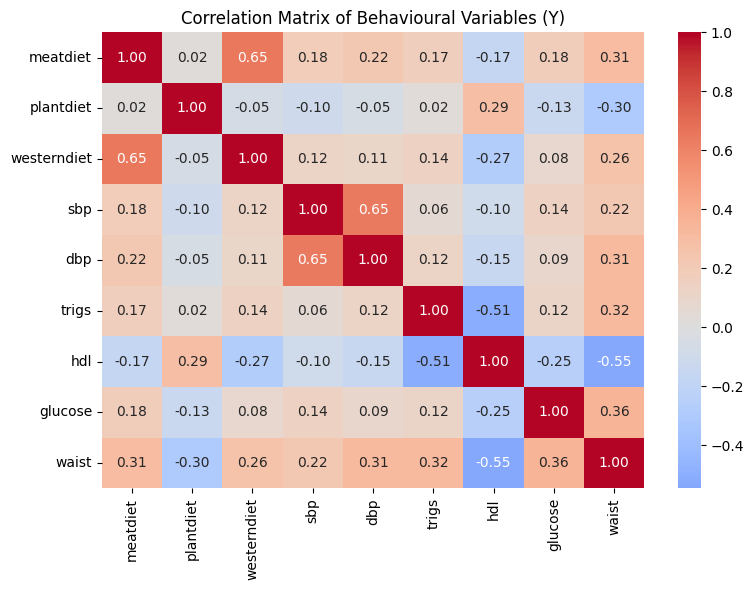

In [ ]:
# Reconstruct DataFrame from Y for inspection
Y_df = pd.DataFrame(Y, columns=[
    'meatdiet', 'plantdiet', 'westerndiet',
    'sbp', 'dbp', 'trigs', 'hdl', 'glucose', 'waist'
])

# Compute correlation matrix
corr_matrix = Y_df.corr()

# Visualise with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix of Behavioural Variables (Y)")
plt.tight_layout()
plt.show()



# Run the PLS

### Setup imports and file paths

### Fit model

In [ ]:
# =============================================================================
# 7. Fit Behavioral PLS (Raw X, Standardised Y)
# =============================================================================

import pyls

# Run PLS with raw neuroimaging data and standardised behavioural data
pls2 = pyls.behavioral_pls(
    X,         # Raw FC matrix (NOT z-scored or Fisher transformed)
    Y,         # Standardised behavioural matrix
    n_boot=1000,
    n_perm=1000,
    seed=1,
    n_proc='max'  # Use all available CPU cores
)

print("PLS model fit successfully using RAW neuroimaging data and STANDARDISED behavioural data.")



PLS model fit successfully using RAW neuroimaging data and STANDARDISED behavioural data.


In [ ]:
# 1a. Grab singular values
singvals = pls2.singvals  

# 1b. Compute % covariance explained
var_explained = singvals**2 / np.sum(singvals**2)

# 1c. Print a little table
for i, (s, v) in enumerate(zip(singvals, var_explained), start=1):
    print(f"LV{i}: S={s:.2f}, explains {v*100:.1f}% of the covariance")


LV1: S=57.26, explains 59.3% of the covariance
LV2: S=28.59, explains 14.8% of the covariance
LV3: S=21.06, explains 8.0% of the covariance
LV4: S=17.59, explains 5.6% of the covariance
LV5: S=15.22, explains 4.2% of the covariance
LV6: S=13.16, explains 3.1% of the covariance
LV7: S=10.94, explains 2.2% of the covariance
LV8: S=9.21, explains 1.5% of the covariance
LV9: S=8.40, explains 1.3% of the covariance


In [ ]:
# p-values for each LV from your permutation test
pvals = pls2.permres['pvals']  
for i, p in enumerate(pvals, start=1):
    print(f"LV{i} p-value: {p:.3f}")


LV1 p-value: 0.018
LV2 p-value: 0.166
LV3 p-value: 0.631
LV4 p-value: 0.798
LV5 p-value: 0.973
LV6 p-value: 0.705
LV7 p-value: 0.935
LV8 p-value: 0.975
LV9 p-value: 0.995


### Save PLS

In [ ]:
# =============================================================================
# 8. Save the Fitted Behavioral PLS Model
# =============================================================================

# Define path to save model
pkl_filename = os.path.join(results_dir, 'pls_behavioral_model_cleanedXY.pkl')

# Ensure results directory exists
os.makedirs(results_dir, exist_ok=True)

# Save the fitted PLS object to disk for reuse or inspection
with open(pkl_filename, 'wb') as f:
    pickle.dump(pls2, f)

print(f"PLS model saved successfully to:\n{pkl_filename}")


PLS model saved successfully to:
C:\Users\c3371138\projects\data\raw\export\Results\rest_pls\pls_behavioral_model_cleanedXY.pkl


### Load PLS result

In [ ]:
# =============================================================================
# 9. Load the Saved PLS Model (Cleaned X/Y Version)
# =============================================================================

# Define the path to the saved model
pkl_filename = os.path.join(results_dir, 'pls_behavioral_model_cleanedXY.pkl')

# Load the model
with open(pkl_filename, 'rb') as file:
    pls2 = pickle.load(file)

# Confirm successful load and inspect model contents
print(" PLS model loaded successfully.")
print("Available attributes in the loaded PLS object:", pls2.__dict__.keys())


 PLS model loaded successfully.
Available attributes in the loaded PLS object: dict_keys([])


In [ ]:
# =============================================================================
# 10. Reload PLS Model and Inspect Core Attributes
# =============================================================================

# Path to the saved model
pkl_filename = os.path.join(results_dir, 'pls_behavioral_model_cleanedXY.pkl')

# Reload the model
with open(pkl_filename, 'rb') as file:
    pls2 = pickle.load(file)

# Print available attributes for inspection
print("✅ PLS model reloaded.")
print("Available attributes in the PLS object:")
for key in pls2.__dict__.keys():
    print(f"  - {key}")



✅ PLS model reloaded.
Available attributes in the PLS object:


# Question 1

Of what behavioral features are the behavioral latent variables composed, and how?

# Loadings plot

For the behavioral variables, plot how they load on their latent variables

OLD INTERPRETATION --> 1. The first component is mainly western diet, meat diet, and waist size. The second component is mainly `SBP` and `DBP`, and also lower western diet.

In [ ]:
# Convert Y (standardised behavioural matrix) back into a DataFrame for bootstrapping
Y_input = pd.DataFrame(Y, columns=[
    'meatdiet', 'plantdiet', 'westerndiet',
    'sbp', 'dbp', 'trigs', 'hdl', 'glucose', 'waist'
])

# Extract LV1 subject scores from PLS result
y_scores = pls2.y_scores[:, 0]  # LV1 scores for each subject

n_boot = 1000  # or match your PLS run

# Array to store bootstrapped r for each variable
boot_rs = np.zeros((len(Y_input.columns), n_boot))

rng = np.random.default_rng(seed=42)

for b in range(n_boot):
    # Resample subjects with replacement
    idx = rng.integers(0, Y_input.shape[0], Y_input.shape[0])
    Y_boot = Y_input.iloc[idx].reset_index(drop=True)
    y_scores_boot = y_scores[idx]

    # Compute Pearson's r for each variable with LV1 scores in this bootstrap
    for i, col in enumerate(Y_input.columns):
        boot_rs[i, b] = np.corrcoef(Y_boot[col], y_scores_boot)[0, 1]

# For each variable: mean r, SE, 95% CI, and BSR
r_mean = np.mean(boot_rs, axis=1)
r_se = np.std(boot_rs, axis=1, ddof=1)
r_ci_lower = np.percentile(boot_rs, 2.5, axis=1)
r_ci_upper = np.percentile(boot_rs, 97.5, axis=1)
r_bsr = r_mean / r_se

bsr_df = pd.DataFrame({
    'variable': Y_input.columns,
    'r_mean': r_mean,
    'r_se': r_se,
    'r_ci_lower': r_ci_lower,
    'r_ci_upper': r_ci_upper,
    'r_bsr': r_bsr
})

print(bsr_df.sort_values('r_bsr', ascending=False).round(3))



      variable  r_mean   r_se  r_ci_lower  r_ci_upper   r_bsr
8        waist   0.702  0.035       0.630       0.770  19.958
4          dbp   0.610  0.049       0.512       0.698  12.385
3          sbp   0.615  0.050       0.514       0.708  12.358
0     meatdiet   0.568  0.055       0.455       0.666  10.345
2  westerndiet   0.558  0.054       0.448       0.662  10.298
7      glucose   0.523  0.052       0.411       0.617  10.116
5        trigs   0.414  0.065       0.284       0.538   6.342
1    plantdiet  -0.227  0.089      -0.399      -0.038  -2.548
6          hdl  -0.590  0.051      -0.689      -0.489 -11.524


---

### 🔍 Bootstrapped Pearson's *r* for Behavioural Loadings (LV1)

The figure below displays the bootstrapped Pearson correlation coefficients (*r*, mean ± 95% CI) between each behavioural variable and the LV1 subject scores from the PLS analysis.

- **Interpretation:**  
  Variables with confidence intervals that do **not cross zero** (highlighted in red) are robustly associated with the LV1 latent variable across bootstrap resamples. This approach matches best-practice for assessing stability of behavioural loadings, as recommended by Voigt et al. (2023).

- **Why this approach?**  
  While PLS saliences (weights) show the structural multivariate importance of each variable, the correlation with LV scores (*r*) provides an interpretable measure of how strongly each observed behaviour aligns with the extracted latent pattern. Bootstrapped CIs offer a rigorous test of stability, moving beyond single-sample estimates.

- **Reference:**  
  > “Cognitive loadings were computed as the Pearson’s correlations between cognitive variables and the PLS analysis-derived cognition scores across the cohort… Bootstrapping is also used to construct 95% confidence intervals on the brain-cognition correlations.”  
  — Voigt et al. (2023), _Metabolic & functional connectivity cog-connectome_, Nature Communications

---



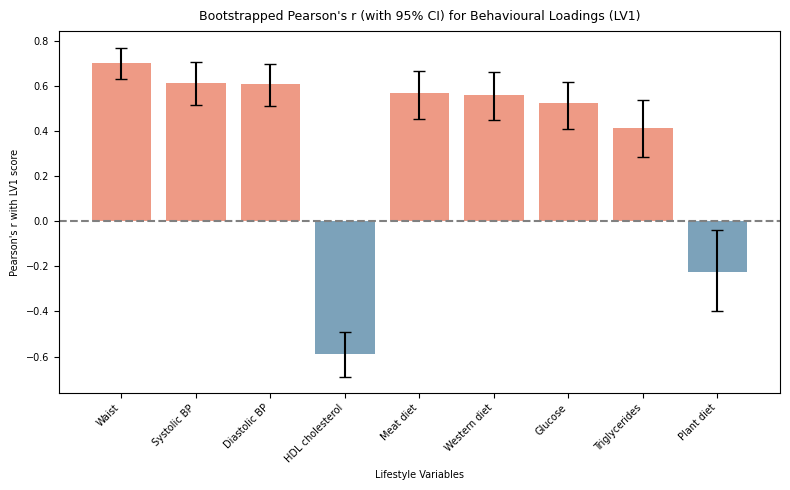

In [ ]:
# Sort by absolute r_mean for visual clarity
plot_df = bsr_df.copy().set_index('variable')
plot_df = plot_df.reindex(plot_df.r_mean.abs().sort_values(ascending=False).index)

# Define your preferred pretty labels
pretty_labels = {
    'waist': 'Waist',
    'sbp': 'Systolic BP',
    'dbp': 'Diastolic BP',
    'hdl': 'HDL cholesterol',
    'meatdiet': 'Meat diet',
    'westerndiet': 'Western diet',
    'glucose': 'Glucose',
    'trigs': 'Triglycerides',
    'plantdiet': 'Plant diet'
}

# Replace index with pretty labels (maintaining sorted order)
plot_df_pretty = plot_df.copy()
plot_df_pretty.index = [pretty_labels[var] for var in plot_df.index]

# Define colors: red for positive, blue for negative
colors = ['#e76f51' if r >= 0 else '#457b9d' for r in plot_df.r_mean]

# Plotting
SMALL_SIZE = 7
TITLE_SIZE = 9

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_df_pretty.index, plot_df_pretty.r_mean,
    yerr=[plot_df_pretty.r_mean - plot_df_pretty.r_ci_lower, plot_df_pretty.r_ci_upper - plot_df_pretty.r_mean],
    capsize=4, color=colors, alpha=0.7
)

ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel("Pearson's r with LV1 score", fontsize=SMALL_SIZE)
ax.set_xlabel("Lifestyle Variables", fontsize=SMALL_SIZE)
ax.set_title("Bootstrapped Pearson's r (with 95% CI) for Behavioural Loadings (LV1)", fontsize=TITLE_SIZE, pad=8)
plt.xticks(rotation=45, ha='right', fontsize=SMALL_SIZE)
plt.yticks(fontsize=SMALL_SIZE)

ax.tick_params(axis='x', labelsize=SMALL_SIZE)
ax.tick_params(axis='y', labelsize=SMALL_SIZE)

ax.grid(False)
plt.tight_layout()
plt.show()


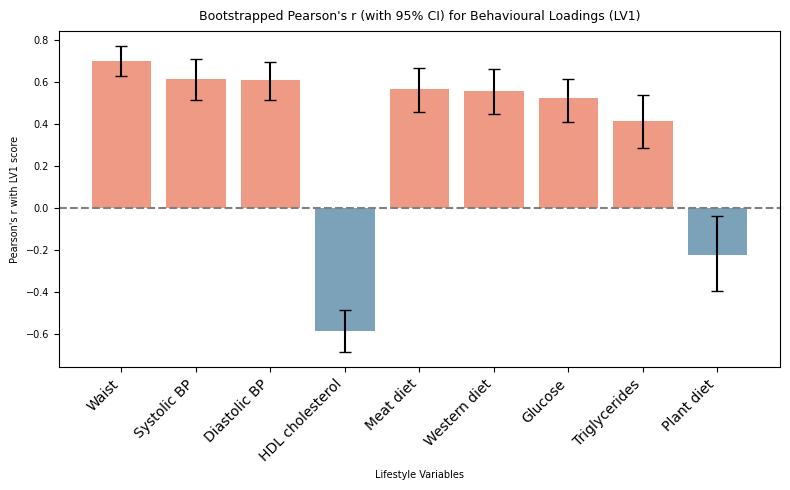

In [ ]:
# Set custom font sizes
SMALL_SIZE = 7         # General small text (e.g., y-axis ticks)
TITLE_SIZE = 9         # Title font
X_LABEL_SIZE = 10      # Font size for x-axis tick labels (lifestyle vars)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_df_pretty.index, plot_df_pretty.r_mean,
    yerr=[plot_df_pretty.r_mean - plot_df_pretty.r_ci_lower, plot_df_pretty.r_ci_upper - plot_df_pretty.r_mean],
    capsize=4, color=colors, alpha=0.7
)

ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel("Pearson's r with LV1 score", fontsize=SMALL_SIZE)
ax.set_xlabel("Lifestyle Variables", fontsize=SMALL_SIZE)
ax.set_title("Bootstrapped Pearson's r (with 95% CI) for Behavioural Loadings (LV1)", fontsize=TITLE_SIZE, pad=8)

# ⬇️ Set larger font for x-axis labels (the lifestyle variables)
plt.xticks(rotation=45, ha='right', fontsize=X_LABEL_SIZE)
plt.yticks(fontsize=SMALL_SIZE)

ax.tick_params(axis='y', labelsize=SMALL_SIZE)

ax.grid(False)
plt.tight_layout()
plt.show()


## Question 1b)
Before regressing the lifestyle variables onto the imaging latent (LV1), we extract the imaging LV1 scores (`u₁ = pls2.x_scores[:, 0]`). 

These scores represent each participant’s expression of the brain connectivity pattern identified by PLS, providing the predictor for subsequent cardiometabolic-risk regressions.



# Question 2

What brain features are significantly loading onto their components?

* For each latent variable (2 were significant), there are significant brain features with positive weights, and negative weights. The higher that a positive functional correlation is that also has a positive weight means this functional correlation in the brain is a stronger contributor to the latent variable. Negative weights implies that this correlation should be weaker, or even negative (and significant).

NOTE: to interpret the negative weights requires having an interpretation of a negative functional connectivity.

In [ ]:
# For each latent variable, get the column indices of significant pos and neg weighted features

# =============================================================================
# Extract Bootstrap Ratios (BSRs) from the PLS Results
# =============================================================================
# The BSRs (bootstrap ratios) are the x_weights normalized by their bootstrap standard errors.
# Typically, an absolute BSR > 2 indicates that an edge is significantly related to the latent variable.
#
# Here, assume that pls2.bootres.x_weights_normed is a NumPy array with shape
# (number_of_edges, number_of_latent_components). For clarity, extract the BSRs
# for the first latent variable (LV1):

BSR_LV1 = pls2.bootres.x_weights_normed[:, 0]  # Bootstrap ratios for LV1
BSR_LV2 = pls2.bootres.x_weights_normed[:, 1]  # Bootstrap ratios for LV2

# indices of significant positively and negatively weighted features
significant_brain_features = {
    'LV1': {'positive': np.where(BSR_LV1 > 2)[0], 'negative': np.where(BSR_LV1 < -2)[0]},
    'LV2': {'positive': np.where(BSR_LV2 > 2)[0], 'negative': np.where(BSR_LV2 < -2)[0]},
}

print("Number of significant positive features for LV1:", len(significant_brain_features['LV1']['positive']))
print("Number of significant negative features for LV1:", len(significant_brain_features['LV1']['negative']))
print("Number of significant positive features for LV2:", len(significant_brain_features['LV2']['positive']))
print("Number of significant negative features for LV2:", len(significant_brain_features['LV2']['negative']))

Number of significant positive features for LV1: 24602
Number of significant negative features for LV1: 122
Number of significant positive features for LV2: 7011
Number of significant negative features for LV2: 1324


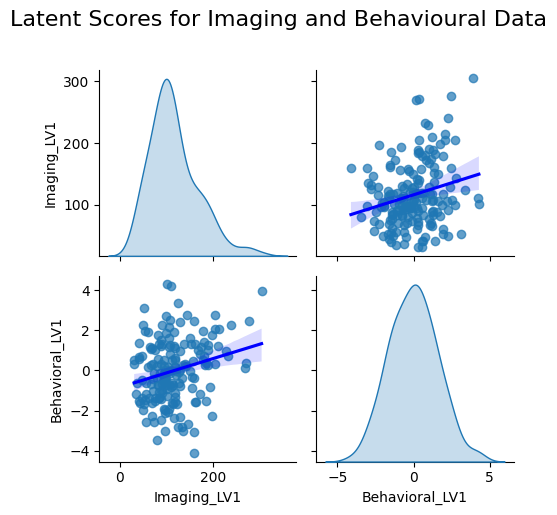

In [ ]:
# %% [markdown]
# ## Pairplot of Latent Variable Scores (Brain and Behaviour)

# %%
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Correct attributes from pyls output
brain_scores = pls2.x_scores[:, :1]  # Imaging LV1 and LV2
behaviour_scores = pls2.y_scores[:, :1]  # Behavioural LV1 and LV2

# Create a DataFrame for plotting
latent_df = pd.DataFrame({
    'Imaging_LV1': brain_scores[:, 0],
  #  'Imaging_LV2': brain_scores[:, 1],
    'Behavioral_LV1': behaviour_scores[:, 0],
  #  'Behavioral_LV2': behaviour_scores[:, 1]
})

# Generate the pairplot
sns.pairplot(latent_df, kind="reg", plot_kws={'scatter_kws': {'alpha':0.7}, 'line_kws': {'color': 'blue'}}, diag_kind='kde')

plt.suptitle('Latent Scores for Imaging and Behavioural Data', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import pandas as pd

# 4a. Your bootstrap ratios for the imaging saliences
BSR_LV1 = pls2.bootres.x_weights_normed[:, 0]

# 4b. Find indices of “significant” edges (|BSR|>2)
sig_pos = np.where(BSR_LV1 > 2)[0]
sig_neg = np.where(BSR_LV1 < -2)[0]

print(f"{len(sig_pos)} edges with BSR>2  (positive weights)")
print(f"{len(sig_neg)} edges with BSR<-2 (negative weights)")

# 4c. Map those indices back to ROI pairs
# (using your existing mask + triu_indices code)
n_rois = int((1 + np.sqrt(1 + 8*X.shape[1]))/2)
tri_i, tri_j = np.triu_indices(n_rois, k=1)
edge_mask   = np.load(os.path.join(output_dir, 'original_edge_mask.npy'))
parcel1_all = tri_i[edge_mask]
parcel2_all = tri_j[edge_mask]

sig_df = pd.DataFrame({
    'edge_idx':   np.concatenate([sig_pos, sig_neg]),
    'parcel1':    np.concatenate([parcel1_all[sig_pos], parcel1_all[sig_neg]]),
    'parcel2':    np.concatenate([parcel2_all[sig_pos], parcel2_all[sig_neg]]),
    'BSR_LV1':    np.concatenate([BSR_LV1[sig_pos], BSR_LV1[sig_neg]])
})

# 4d. Sort by absolute BSR and inspect top entries
sig_df = sig_df.reindex(sig_df.BSR_LV1.abs().sort_values(ascending=False).index)
print(sig_df.head(20))


24602 edges with BSR>2  (positive weights)
122 edges with BSR<-2 (negative weights)
       edge_idx  parcel1  parcel2   BSR_LV1
24523     79672      383      392  5.206743
23606     77791      336      344  5.161452
12170     41496      122      322  5.077242
24464     79582      378      392  4.811325
23820     78068      340      379  4.733333
17489     57373      187      339  4.688842
797        2868        7      104  4.681865
24467     79585      378      395  4.667204
22604     75162      303      322  4.621329
18954     63627      219      337  4.602146
21801     72338      277      319  4.591356
9599      31161       87      277  4.585482
15971     52644      166      272  4.530175
12099     41407      122      233  4.476277
22781     75534      307      320  4.463037
17490     57374      187      340  4.457987
6649      23278       63      158  4.454903
4069      13641       35      307  4.451936
3067      10713       27      319  4.451315
24586     79775      392      396  4

In [ ]:
# ———————————————————————————————
# Map significant edges to network labels
# ———————————————————————————————
import os

# 1. Load the mapping file
mapping_path = os.path.join(mapping_dir, 'CombinedMapping.csv')
mapping_df   = pd.read_csv(mapping_path)  # expects columns ['ParcelIndex', 'Label17', ...]

# 2. For each edge in sig_df, grab its network label
#    (Note: parcel1_all and parcel2_all were already defined when you built sig_df)
sig_df['net1'] = mapping_df.loc[sig_df['parcel1'], 'Label17'].values
sig_df['net2'] = mapping_df.loc[sig_df['parcel2'], 'Label17'].values

# 3. (Optional) Simplify the network names to root strings
def simplify(label):
    lab = label.replace('17Networks_', '').replace('LH_', '').replace('RH_', '')
    return lab.split('_')[0]

sig_df['net1_simple'] = sig_df['net1'].map(simplify)
sig_df['net2_simple'] = sig_df['net2'].map(simplify)

# 4. Rearrange and show the top 20 by absolute BSR
display_cols = ['edge_idx', 'parcel1', 'net1_simple', 'parcel2', 'net2_simple', 'BSR_LV1']
final_sig = sig_df[display_cols].head(20)
print(final_sig.to_string(index=False))


 edge_idx  parcel1  net1_simple  parcel2  net2_simple  BSR_LV1
    79672      383     DefaultB      392      TempPar 5.206743
    77791      336        ContB      344        ContB 5.161452
    41496      122        ContA      322      LimbicA 5.077242
    79582      378     DefaultB      392      TempPar 4.811325
    78068      340        ContB      379     DefaultB 4.733333
    57373      187     DefaultC      339        ContB 4.688842
     2868        7      VisCent      104 SalVentAttnB 4.681865
    79585      378     DefaultB      395      TempPar 4.667204
    75162      303 SalVentAttnB      322      LimbicA 4.621329
    63627      219      VisPeri      337        ContB 4.602146
    72338      277    DorsAttnB      319      LimbicA 4.591356
    31161       87 SalVentAttnA      277    DorsAttnB 4.585482
    52644      166     DefaultB      272    DorsAttnB 4.530175
    41407      122        ContA      233      SomMotA 4.476277
    75534      307 SalVentAttnB      320      LimbicA 4

In [ ]:
# ———————————————————————————————
# Summarise network‐pair contributions to LV1
# ———————————————————————————————
network_summary = (
    sig_df
    .groupby(['net1_simple','net2_simple'])
    .agg(
        count   = ('BSR_LV1','size'),
        mean_BSR= ('BSR_LV1','mean')
    )
    .reset_index()
    .sort_values('count', ascending=False)
)

# Look at the top 10 network pairs
print(network_summary.head(10).to_string(index=False))


 net1_simple  net2_simple  count  mean_BSR
     SomMotA SalVentAttnA    427  2.569047
     SomMotA     DefaultB    377  2.583105
   DorsAttnA SalVentAttnA    368  2.676813
     SomMotA        ContB    366  2.658592
     VisCent     DefaultB    351  2.709819
   DorsAttnB     DefaultB    314  2.641159
    DefaultB      TempPar    294  2.752769
     SomMotA        ContA    289  2.523099
SalVentAttnA     DefaultB    286  2.507185
   DorsAttnB SalVentAttnA    285  2.582080


In [ ]:
network_summary = (
    sig_df
    .groupby(['net1_simple','net2_simple'])
    .agg(
        count   = ('BSR_LV1','size'),
        mean_BSR= ('BSR_LV1','mean')
    )
    .reset_index()
    .sort_values('count', ascending=False)
)
print(network_summary.head(30).to_string(index=False))


 net1_simple  net2_simple  count  mean_BSR
     SomMotA SalVentAttnA    427  2.569047
     SomMotA     DefaultB    377  2.583105
   DorsAttnA SalVentAttnA    368  2.676813
     SomMotA        ContB    366  2.658592
     VisCent     DefaultB    351  2.709819
   DorsAttnB     DefaultB    314  2.641159
    DefaultB      TempPar    294  2.752769
     SomMotA        ContA    289  2.523099
SalVentAttnA     DefaultB    286  2.507185
   DorsAttnB SalVentAttnA    285  2.582080
     VisPeri     DefaultB    278  2.553793
   DorsAttnA     DefaultB    274  2.559697
     SomMotA SalVentAttnB    273  2.733781
     SomMotA    DorsAttnA    272  2.468543
     SomMotB        ContB    265  2.474480
       ContB      TempPar    240  2.811988
     SomMotB    DorsAttnA    238  2.463328
       ContA     DefaultB    226  2.616388
       ContB     DefaultB    224  2.773098
     VisPeri        ContB    221  2.560936
   DorsAttnB     DefaultA    220  2.551595
     VisPeri     DefaultA    219  2.562091
     SomMot

In [ ]:
import numpy as np
import pandas as pd

# 1) Compute BSR_LV1 if you haven’t already:
#    (assumes pls2.bootres.x_weights_normed[:,0] exists)
BSR_LV1 = pls2.bootres.x_weights_normed[:, 0]

# 2) Find the indices of “significant” edges:
sig_pos = np.where(BSR_LV1 >  2)[0]
sig_neg = np.where(BSR_LV1 < -2)[0]

# 3) Reconstruct parcel‐pairs for every edge (you already inferred these):
n_rois      = int((1 + np.sqrt(1 + 8 * X.shape[1])) / 2)
tri_i,tri_j = np.triu_indices(n_rois, k=1)
edge_mask   = np.load(os.path.join(output_dir, 'original_edge_mask.npy'))
parcel1_all = tri_i[edge_mask]
parcel2_all = tri_j[edge_mask]

# 4) Build sig_df:
sig_df = pd.DataFrame({
    'edge_idx': np.concatenate([sig_pos, sig_neg]),
    'parcel1' : np.concatenate([parcel1_all[sig_pos],    parcel1_all[sig_neg]]),
    'parcel2' : np.concatenate([parcel2_all[sig_pos],    parcel2_all[sig_neg]]),
    'BSR_LV1' : np.concatenate([BSR_LV1[sig_pos],        BSR_LV1[sig_neg]])
})

# Now sig_df exists and you can map to networks, group, count, etc.


In [ ]:
# ———————————————————————————————
# 5. Map significant edges to 7-network labels
# ———————————————————————————————
import os
import pandas as pd

# create a 0-based index for mapping_df
mapping_df = pd.read_csv(os.path.join(mapping_dir, 'CombinedMapping.csv'))
mapping_df.index = mapping_df['ParcelID'] - 1   # now 0-based
# you can optionally drop the old ParcelID column
mapping_df = mapping_df.drop(columns='ParcelID')

# now you can do
sig_df['net1'] = mapping_df.loc[sig_df['parcel1'], 'Label7'].values
sig_df['net2'] = mapping_df.loc[sig_df['parcel2'], 'Label7'].values


# Simplify "7Networks_LH_Vis_1" → "Vis"
def simplify7(label):
    # Keep only the network name (drop prefix and hemisphere)
    # e.g. 7Networks_LH_Default_2 → Default
    return label.split('_')[2]

sig_df['net1_simple'] = sig_df['net1'].map(simplify7)
sig_df['net2_simple'] = sig_df['net2'].map(simplify7)

# ———————————————————————————————
# 6. Summarise network-pair contributions (7×7)
# ———————————————————————————————
network_summary_7 = (
    sig_df
    .groupby(['net1_simple', 'net2_simple'])
    .agg(
        edge_count=('BSR_LV1', 'size'),
        mean_BSR   =('BSR_LV1', 'mean')
    )
    .reset_index()
    .sort_values('edge_count', ascending=False)
)

# Show the top 10 most represented network pairs
print(network_summary_7.head(30))


    net1_simple  net2_simple  edge_count  mean_BSR
43          Vis      Default        1559  2.590179
36       SomMot      Default        1498  2.485687
1          Cont      Default        1265  2.672353
15     DorsAttn      Default        1231  2.557411
35       SomMot         Cont        1216  2.509609
8       Default      Default        1199  2.459706
42          Vis         Cont        1063  2.587952
37       SomMot     DorsAttn         873  2.556545
39       SomMot  SalVentAttn         800  2.545986
29  SalVentAttn      Default         754  2.541592
22       Limbic      Default         638  2.625167
38       SomMot       Limbic         616  2.605008
40       SomMot       SomMot         612  2.439272
14     DorsAttn         Cont         597  2.477199
46          Vis  SalVentAttn         553  2.616544
12      Default       SomMot         543  2.492562
47          Vis       SomMot         513  2.398489
13      Default          Vis         503  2.484883
0          Cont         Cont   

In [ ]:
print(network_summary_7)


    net1_simple  net2_simple  edge_count  mean_BSR
43          Vis      Default        1559  2.590179
36       SomMot      Default        1498  2.485687
1          Cont      Default        1265  2.672353
15     DorsAttn      Default        1231  2.557411
35       SomMot         Cont        1216  2.509609
8       Default      Default        1199  2.459706
42          Vis         Cont        1063  2.587952
37       SomMot     DorsAttn         873  2.556545
39       SomMot  SalVentAttn         800  2.545986
29  SalVentAttn      Default         754  2.541592
22       Limbic      Default         638  2.625167
38       SomMot       Limbic         616  2.605008
40       SomMot       SomMot         612  2.439272
14     DorsAttn         Cont         597  2.477199
46          Vis  SalVentAttn         553  2.616544
12      Default       SomMot         543  2.492562
47          Vis       SomMot         513  2.398489
13      Default          Vis         503  2.484883
0          Cont         Cont   

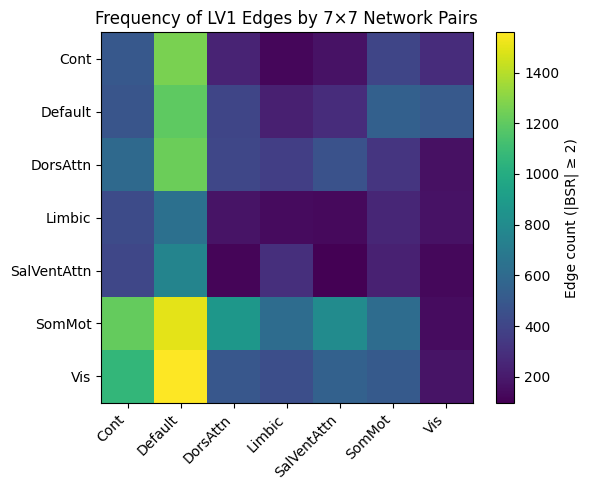

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume network_summary_7 is your DataFrame
# Pivot to matrix form
cnt_matrix = network_summary_7.pivot(
    index='net1_simple', columns='net2_simple', values='edge_count'
).fillna(0)

plt.figure(figsize=(6,5))
plt.imshow(cnt_matrix, aspect='auto')
plt.colorbar(label='Edge count (|BSR| ≥ 2)')
plt.xticks(range(len(cnt_matrix.columns)), cnt_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(cnt_matrix.index)), cnt_matrix.index)
plt.title('Frequency of LV1 Edges by 7×7 Network Pairs')
plt.tight_layout()
plt.show()


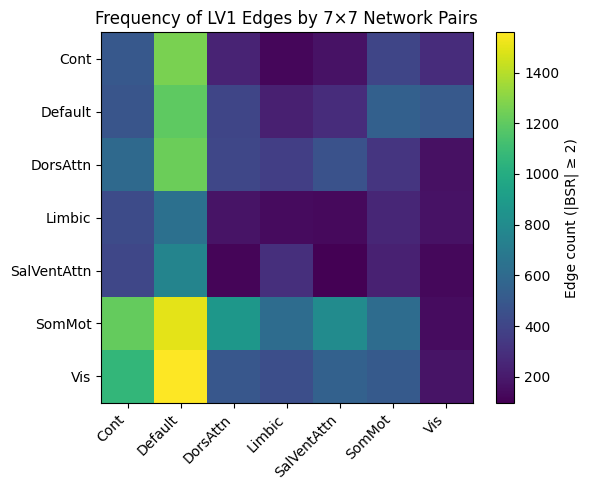

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume network_summary_7 is your DataFrame
# Pivot to matrix form
cnt_matrix = network_summary_7.pivot(
    index='net1_simple', columns='net2_simple', values='edge_count'
).fillna(0)

plt.figure(figsize=(6,5))
plt.imshow(cnt_matrix, aspect='auto')
plt.colorbar(label='Edge count (|BSR| ≥ 2)')
plt.xticks(range(len(cnt_matrix.columns)), cnt_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(cnt_matrix.index)), cnt_matrix.index)
plt.title('Frequency of LV1 Edges by 7×7 Network Pairs')
plt.tight_layout()
plt.show()


In [ ]:
# 1) Compute total number of significant edges (both positive & negative)
total_sig_edges = sig_df.shape[0]

# 2) Add a new column to network_summary_7
network_summary_7['pct_of_total'] = (
    network_summary_7['edge_count'] / total_sig_edges * 100
).round(2)  # round to 2 decimal places

# 3) View the updated top 10
print(network_summary_7.head(30).to_string(index=False))


net1_simple net2_simple  edge_count  mean_BSR  pct_of_total
        Vis     Default        1559  2.590179          6.31
     SomMot     Default        1498  2.485687          6.06
       Cont     Default        1265  2.672353          5.12
   DorsAttn     Default        1231  2.557411          4.98
     SomMot        Cont        1216  2.509609          4.92
    Default     Default        1199  2.459706          4.85
        Vis        Cont        1063  2.587952          4.30
     SomMot    DorsAttn         873  2.556545          3.53
     SomMot SalVentAttn         800  2.545986          3.24
SalVentAttn     Default         754  2.541592          3.05
     Limbic     Default         638  2.625167          2.58
     SomMot      Limbic         616  2.605008          2.49
     SomMot      SomMot         612  2.439272          2.48
   DorsAttn        Cont         597  2.477199          2.41
        Vis SalVentAttn         553  2.616544          2.24
    Default      SomMot         543  2.4

# What about by BSR ranking

In [ ]:
# Sort by BSR for top positive and negative edges
top_pos = sig_df.sort_values('BSR_LV1', ascending=False).head(10)
top_neg = sig_df.sort_values('BSR_LV1').head(10)

# Concatenate for one table (optional: add column 'Direction' for clarity)
top_edges = pd.concat([
    top_pos.assign(Direction='Positive'),
    top_neg.assign(Direction='Negative')
], ignore_index=True)

# Select/rename columns for clarity
top_edges = top_edges[[
    'parcel1', 'net1', 'parcel2', 'net2', 'BSR_LV1', 'Direction'
]].rename(columns={
    'parcel1': 'ROI 1', 'net1': 'Network 1',
    'parcel2': 'ROI 2', 'net2': 'Network 2',
    'BSR_LV1': 'BSR (LV1)'
})

# Display or save
print(top_edges.to_string(index=False))
# Or save to CSV if needed
# top_edges.to_csv('top20_BSR_edges_LV1.csv', index=False)


 ROI 1                            Network 1  ROI 2                            Network 2  BSR (LV1) Direction
   383      7Networks_RH_Default_PFCdPFCm_6    392       7Networks_RH_Default_pCunPCC_2   5.206743  Positive
   336              7Networks_RH_Cont_Par_6    344             7Networks_RH_Cont_PFCl_5   5.161452  Positive
   122       7Networks_LH_Limbic_TempPole_5    322            7Networks_RH_Limbic_OFC_5   5.077242  Positive
   378      7Networks_RH_Default_PFCdPFCm_1    392       7Networks_RH_Default_pCunPCC_2   4.811325  Positive
   340             7Networks_RH_Cont_PFCl_1    379      7Networks_RH_Default_PFCdPFCm_2   4.733333  Positive
   187          7Networks_LH_Default_PFC_23    339             7Networks_RH_Cont_PFCv_1   4.688842  Positive
     7                   7Networks_LH_Vis_8    104 7Networks_LH_SalVentAttn_FrOperIns_9   4.681865  Positive
   378      7Networks_RH_Default_PFCdPFCm_1    395       7Networks_RH_Default_pCunPCC_5   4.667204  Positive
   303 7Networks_RH

In [ ]:
import pandas as pd
import numpy as np
import os

# Load the mapping file (ensure correct path and columns)
mapping_path = os.path.join(mapping_dir, 'CombinedMapping.csv')
mapping_df = pd.read_csv(mapping_path)
mapping_df.index = mapping_df['ParcelID'] - 1  # 0-based index

def simplify_label(label):
    label = label.replace("17Networks_", "")
    label = label.replace("LH_", "").replace("RH_", "")
    parts = label.split("_")
    return parts[0] if len(parts) > 1 else label

# Assume sig_df already contains columns 'parcel1', 'parcel2', 'BSR_LV1'
sig_df['net1_17'] = mapping_df.loc[sig_df['parcel1'], 'Label17'].values
sig_df['net2_17'] = mapping_df.loc[sig_df['parcel2'], 'Label17'].values
sig_df['Network 1'] = sig_df['net1_17'].map(simplify_label)
sig_df['Network 2'] = sig_df['net2_17'].map(simplify_label)

# For pretty output, keep only the columns you want
cols = ['parcel1', 'Network 1', 'parcel2', 'Network 2', 'BSR_LV1']

# -----------------------------
# TOP 10 POSITIVE BSR EDGES
# -----------------------------
top_pos_17 = (
    sig_df[sig_df['BSR_LV1'] > 0]
    .sort_values('BSR_LV1', ascending=False)
    .head(10)
    [cols]
    .rename(columns={
        'parcel1': 'ROI 1',
        'parcel2': 'ROI 2',
        'BSR_LV1': 'BSR (LV1)'
    })
)

print("Top 10 Positive BSR Edges (LV1, by 17-network parcellation):")
print(top_pos_17.to_string(index=False))


Top 10 Positive BSR Edges (LV1, by 17-network parcellation):
 ROI 1    Network 1  ROI 2    Network 2  BSR (LV1)
   383     DefaultB    392      TempPar   5.206743
   336        ContB    344        ContB   5.161452
   122        ContA    322      LimbicA   5.077242
   378     DefaultB    392      TempPar   4.811325
   340        ContB    379     DefaultB   4.733333
   187     DefaultC    339        ContB   4.688842
     7      VisCent    104 SalVentAttnB   4.681865
   378     DefaultB    395      TempPar   4.667204
   303 SalVentAttnB    322      LimbicA   4.621329
   219      VisPeri    337        ContB   4.602146


In [ ]:
# Map to simplified 17-network labels, hemisphere removed
sig_df['Network 1'] = sig_df['net1_17'].map(simplify_label)
sig_df['Network 2'] = sig_df['net2_17'].map(simplify_label)

cols = ['parcel1', 'Network 1', 'parcel2', 'Network 2', 'BSR_LV1']

# -----------------------------
# TOP 10 NEGATIVE BSR EDGES
# -----------------------------
top_neg_17 = (
    sig_df[sig_df['BSR_LV1'] < 0]
    .sort_values('BSR_LV1')
    .head(10)
    [cols]
    .rename(columns={
        'parcel1': 'ROI 1',
        'parcel2': 'ROI 2',
        'BSR_LV1': 'BSR (LV1)'
    })
)

print("Top 10 Negative BSR Edges (LV1, by 17-network parcellation):")
print(top_neg_17.to_string(index=False))



Top 10 Negative BSR Edges (LV1, by 17-network parcellation):
 ROI 1 Network 1  ROI 2 Network 2  BSR (LV1)
   161  DefaultA    376  DefaultB  -3.390267
    14   VisPeri    215   VisPeri  -3.321331
    13   VisPeri     22   VisPeri  -3.078313
   163  DefaultA    369  DefaultA  -3.073790
   215   VisPeri    222   VisPeri  -3.046164
    13   VisPeri     20   VisPeri  -3.006482
    17   VisPeri    214   VisPeri  -2.987879
   367  DefaultA    376  DefaultB  -2.954424
     1   VisCent    215   VisPeri  -2.923107
    22   VisPeri    215   VisPeri  -2.915551


# Plot chord diagrams

We generate a chord diagram for each feature set:

* LV1, positive weights
* LV1, negative weights
* LV2, positive weights
* LV2, negative weights

In [ ]:
def plot_chord_diagram(bsr_vector,
                       positive=True,
                       title='',
                       top_n=30,
                       save_image=False,
                       show_colorbar=True,
                       show_legend=True):
    """
    Generate a chord diagram for significant RSFC subnetwork loadings with improved clarity and interpretability.

    Parameters:
    - bsr_vector: Array of bootstrap ratios (e.g., pls2.bootres.x_weights_normed[:, 0] for LV1)
    - positive: Boolean indicating whether to plot positive or negative weights
    - title: String for the plot title
    - top_n: Number of top edges to display (default: 30)
    - save_image: Whether to save the figure as PNG
    - show_colorbar: Whether to draw the BSR colorbar
    - show_legend: Whether to draw the network‐color legend
    """
    from collections import Counter
    from matplotlib.patches import FancyArrowPatch
    from matplotlib.path import Path
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # load mapping & mask (adjust your paths/vars as needed)
    mapping_df = pd.read_csv(os.path.join(mapping_dir, 'CombinedMapping.csv'))
    triu_indices = np.triu_indices(400, k=1)
    mask = np.load(os.path.join(output_dir, 'original_edge_mask.npy'))
    parcel1, parcel2 = triu_indices[0][mask], triu_indices[1][mask]

    # simplify labels
    def simplify_label(label):
        label = label.replace("17Networks_", "")
        label = label.replace("LH_", "").replace("RH_", "")
        parts = label.split("_")
        return parts[0] if len(parts) > 1 else label

    subnet1 = [simplify_label(l) for l in mapping_df.iloc[parcel1]['Label17']]
    subnet2 = [simplify_label(l) for l in mapping_df.iloc[parcel2]['Label17']]

    # build edge DataFrame
    edge_df = pd.DataFrame({
        'pair': list(zip(subnet1, subnet2)),
        'bsr' : bsr_vector
    })
    edge_df = edge_df[edge_df['bsr'] > 0] if positive else edge_df[edge_df['bsr'] < 0]

    # aggregate & pick top_n
    agg_df = (edge_df
              .groupby('pair')['bsr']
              .mean()
              .abs()
              .reset_index(name='abs_bsr')
              .sort_values('abs_bsr', ascending=False)
              .head(top_n))
    agg_df['bsr'] = edge_df.groupby('pair')['bsr'].mean().loc[agg_df['pair']].values

    # unique subnetworks
    unique_subnets = sorted(set(agg_df['pair'].explode()))

    # manual colors
    manual_colors = {
        'ContA': "#61dfb7", 
        'ContB': "#6bebaf", 
        'ContC': "#76d693",
        'DefaultA': "#f05fb8", 
        'DefaultB': "#f775e5", 
        'DefaultC': "#e762c6",
        'DorsAttnA': "#3431e6", 
        'DorsAttnB': "#1511f8",
        'LimbicA': "#e9d07e", 
        'LimbicB': "#c3d902",
        'SalVentAttnA': "#e2b77f", 
        'SalVentAttnB': "#eb8b0d",
        'SomMotA': "#5ac6f8", 
        'SomMotB': "#3bd5e0",
        'TempPar': "#c856eb", 
        'VisCent': "#9506F5", 
        'VisPeri': "#076614",
    }

    # layout
    n = len(unique_subnets)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    x, y = np.cos(angles), np.sin(angles)
    node_sizes = []
    deg = Counter([p for pair in agg_df['pair'] for p in pair])
    maxdeg = max(deg.values()) or 1
    for s in unique_subnets:
        node_sizes.append(10 + 20*(deg[s]/maxdeg))

    # choose colormap
    max_abs_bsr = agg_df['abs_bsr'].max()
    vmin, vmax = 0, max_abs_bsr
    # *** CONVENTIONAL COLOURS: Red = positive, Blue = negative ***
    if positive:
        cmap = plt.get_cmap('Reds')    # Positive BSR: REDS
        cbar_label = 'Positive Mean BSR (0 → +)'
    else:
        cmap = plt.get_cmap('Blues')   # Negative BSR: BLUES
        cbar_label = 'Negative Mean BSR (0 ← −)'
    norm = plt.Normalize(vmin=vmin, vmax=vmax)


    # draw
    fig, ax = plt.subplots(figsize=(14,14))
    # leave the right 20% of the figure free for our colorbar
    fig.subplots_adjust(right=0.75)


    ax.set_aspect('equal'); ax.axis('off')
    ax.add_patch(plt.Circle((0,0),1,color='gray',alpha=0.1,zorder=0))

    # nodes
    for i, s in enumerate(unique_subnets):
        ax.plot(x[i], y[i], 'o', color=manual_colors[s], markersize=node_sizes[i], zorder=2)
        ang = angles[i]*180/np.pi
        ha = 'left' if np.cos(angles[i])>0 else 'right'
        ax.text(x[i]*1.3, y[i]*1.3, s, ha=ha, va='center', fontsize=10, rotation=ang, zorder=3)

    # chords
    for _, row in agg_df.iterrows():
        a, b = row['pair']
        i, j = unique_subnets.index(a), unique_subnets.index(b)
        bval = abs(row['bsr'])
        color = cmap(norm(bval))
        lw = 1 + 5*(bval/max_abs_bsr)
        alpha = min(1, 0.5+0.5*(bval/max_abs_bsr))
        path = Path([[x[i],y[i]],[0,0],[x[j],y[j]]],
                    [Path.MOVETO,Path.CURVE3,Path.CURVE3])
        ax.add_patch(FancyArrowPatch(path=path, facecolor='none',
                                    edgecolor=color, linewidth=lw,
                                    alpha=alpha, zorder=1))

    # … after drawing all the chords …

    # optional colorbar
    if show_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # dummy data for the colorbar
        cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=10, pad=0.2)
        cbar.set_label(cbar_label, fontsize=12)

    # optional network‐colour legend
    if show_legend:
        from matplotlib.lines import Line2D
        legend_elems = [
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label=s,
                   markerfacecolor=manual_colors[s],
                   markersize=10)
            for s in unique_subnets
        ]
        ax.legend(handles=legend_elems,
                  loc='center',
                  bbox_to_anchor=(0.5, -0.3),  # push legend down
                  ncol=3,
                  fontsize=8,
                  title="Subnetworks")

    # tighten and give extra bottom margin
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, right=0.75)


    if save_image:
        plt.savefig(f"{title.lower().replace(' ', '_')}.png",
                    dpi=300, bbox_inches='tight')
    plt.show()



## Positive weights for LV1

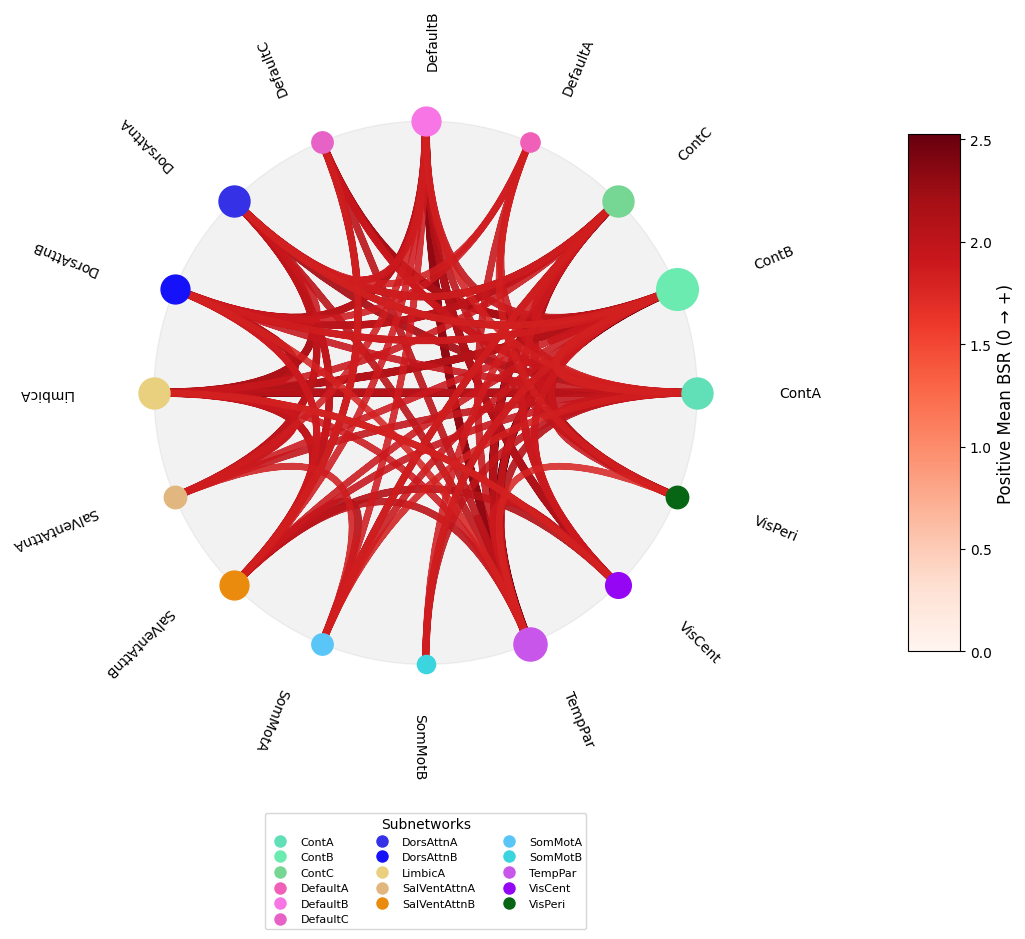

In [ ]:
plot_chord_diagram(
    bsr_vector = BSR_LV1,
    title = "Top 100 Significant RSFC Subnetwork Loadings for LV1 (Chord Style)",
    positive = True, top_n = 100, save_image = False
)

## Negative weights for LV1

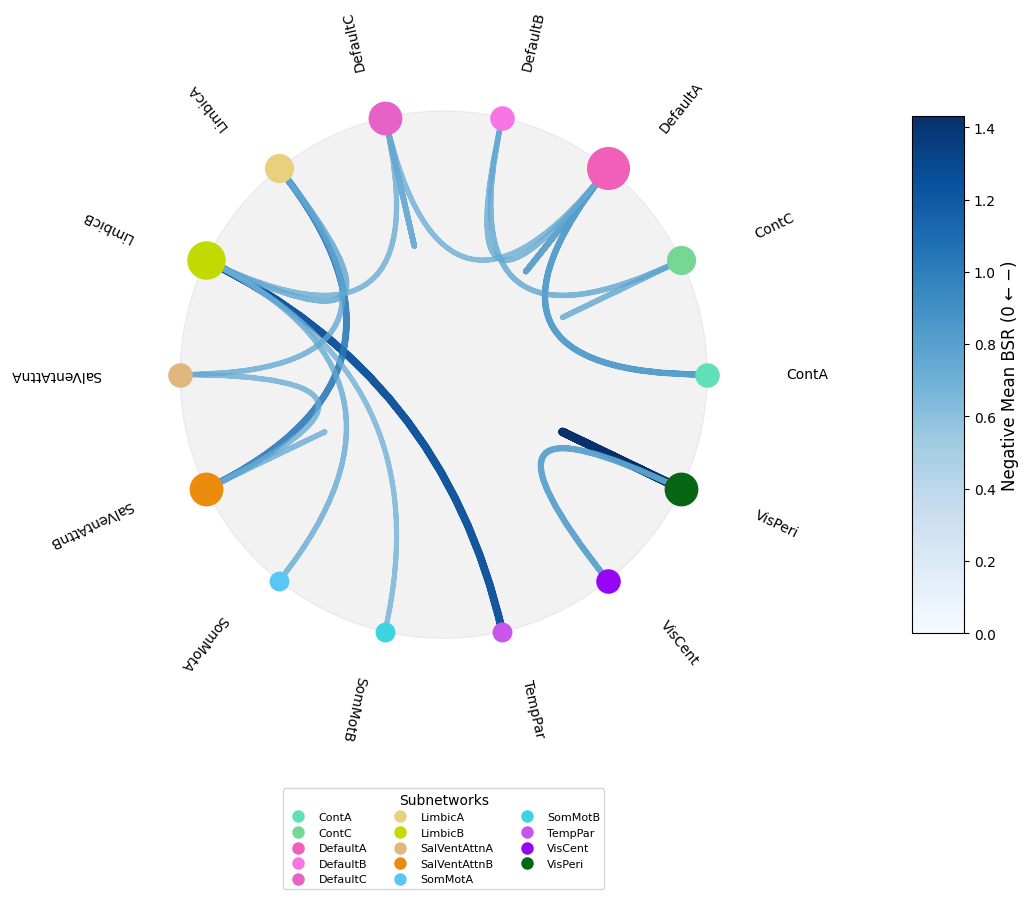

In [ ]:
plot_chord_diagram(
    bsr_vector = BSR_LV1,
    title = "Top 100 Significant RSFC Subnetwork Loadings for LV1 (Chord Style)",
    positive = False, top_n = 20, save_image = False
)

I didn't like the red legend

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap

def plot_chord_diagram(
        bsr_vector,
        mapping_dir,
        output_dir,
        positive=True,
        title='',
        top_n=30,
        save_image=False,
        show_colorbar=True,
        show_legend=True):
    """
    Generate a chord diagram for significant RSFC subnetwork loadings.
    Uses red for positive, blue for negative BSRs, with a white base for clarity.
    """

    # --- Custom colormaps ---
    reds = LinearSegmentedColormap.from_list(
        "custom_reds",
        [(1,1,1), (1,1,1), (1,0.9,0.9), (1,0.5,0.5), (0.8,0,0)],
        N=256
    )
    blues = LinearSegmentedColormap.from_list(
        "custom_blues",
        [(1,1,1), (0.8,0.9,1), (0.5,0.7,1), (0,0,0.8)],
        N=256
    )

    # --- Load mapping ---
    mapping_df = pd.read_csv(os.path.join(mapping_dir, 'CombinedMapping.csv'))
    triu_indices = np.triu_indices(400, k=1)
    mask = np.load(os.path.join(output_dir, 'original_edge_mask.npy'))
    parcel1, parcel2 = triu_indices[0][mask], triu_indices[1][mask]

    def simplify_label(label):
        label = label.replace("17Networks_", "")
        label = label.replace("LH_", "").replace("RH_", "")
        return label.split("_")[0] if "_" in label else label

    subnet1 = [simplify_label(l) for l in mapping_df.iloc[parcel1]['Label17']]
    subnet2 = [simplify_label(l) for l in mapping_df.iloc[parcel2]['Label17']]

    # --- Build edge DataFrame ---
    edge_df = pd.DataFrame({
        'pair': list(zip(subnet1, subnet2)),
        'bsr': bsr_vector
    })
    edge_df = edge_df[edge_df['bsr'] > 0] if positive else edge_df[edge_df['bsr'] < 0]

    # --- Aggregate top edges ---
    agg_df = (edge_df
              .groupby('pair')['bsr']
              .mean()
              .abs()
              .reset_index(name='abs_bsr')
              .sort_values('abs_bsr', ascending=False)
              .head(top_n))
    agg_df['bsr'] = edge_df.groupby('pair')['bsr'].mean().loc[agg_df['pair']].values

    unique_subnets = sorted(set([p for pair in agg_df['pair'] for p in pair]))
    n = len(unique_subnets)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    x, y = np.cos(angles), np.sin(angles)
    node_sizes = []
    deg = Counter([p for pair in agg_df['pair'] for p in pair])
    maxdeg = max(deg.values()) or 1
    for s in unique_subnets:
        node_sizes.append(10 + 20*(deg[s]/maxdeg))

    manual_colors = {
        'ContA': "#61dfb7", 'ContB': "#6bebaf", 'ContC': "#76d693",
        'DefaultA': "#f05fb8", 'DefaultB': "#f775e5", 'DefaultC': "#e762c6",
        'DorsAttnA': "#3431e6", 'DorsAttnB': "#1511f8",
        'LimbicA': "#e9d07e", 'LimbicB': "#c3d902",
        'SalVentAttnA': "#e2b77f", 'SalVentAttnB': "#eb8b0d",
        'SomMotA': "#5ac6f8", 'SomMotB': "#3bd5e0",
        'TempPar': "#c856eb", 'VisCent': "#9506F5", 'VisPeri': "#076614",
    }

    max_abs_bsr = agg_df['abs_bsr'].max()
    vmin, vmax = 0, max_abs_bsr
    if positive:
        cmap = reds
        cbar_label = 'Positive BSR'
    else:
        cmap = blues
        cbar_label = 'Negative BSR'
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(14,14))
    fig.subplots_adjust(right=0.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.add_patch(plt.Circle((0,0),1,color='gray',alpha=0.1,zorder=0))

    # nodes
    for i, s in enumerate(unique_subnets):
        ax.plot(x[i], y[i], 'o', color=manual_colors.get(s, 'gray'), markersize=node_sizes[i], zorder=2)
        ang = angles[i]*180/np.pi
        ha = 'left' if np.cos(angles[i])>0 else 'right'
        ax.text(x[i]*1.3, y[i]*1.3, s, ha=ha, va='center', fontsize=10, rotation=ang, zorder=3)

    agg_df_sorted = agg_df.sort_values('abs_bsr')  # weakest first, strongest last    

    # chords
    for _, row in agg_df_sorted.iterrows():
        a, b = row['pair']
        i, j = unique_subnets.index(a), unique_subnets.index(b)
        bval = abs(row['bsr'])
        color = cmap(norm(bval))
        lw = 1 + 5*(bval/max_abs_bsr)
        alpha = min(1, 0.5+0.5*(bval/max_abs_bsr))
        path = Path([[x[i],y[i]],[0,0],[x[j],y[j]]],
                    [Path.MOVETO,Path.CURVE3,Path.CURVE3])
        ax.add_patch(FancyArrowPatch(path=path, facecolor='none',
                                    edgecolor=color, linewidth=lw,
                                    alpha=alpha, zorder=1))

    # colorbar
    if show_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=10, pad=0.2)
        cbar.set_label(cbar_label, fontsize=12)

    # legend
    if show_legend:
        from matplotlib.lines import Line2D
        legend_elems = [
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label=s,
                   markerfacecolor=manual_colors.get(s, 'gray'),
                   markersize=10)
            for s in unique_subnets
        ]
        ax.legend(handles=legend_elems,
                  loc='center',
                  bbox_to_anchor=(0.5, -0.3),
                  ncol=3,
                  fontsize=8,
                  title="Subnetworks")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, right=0.75)

    if save_image:
        plt.savefig(f"{title.lower().replace(' ', '_')}.png",
                    dpi=300, bbox_inches='tight')
    plt.show()




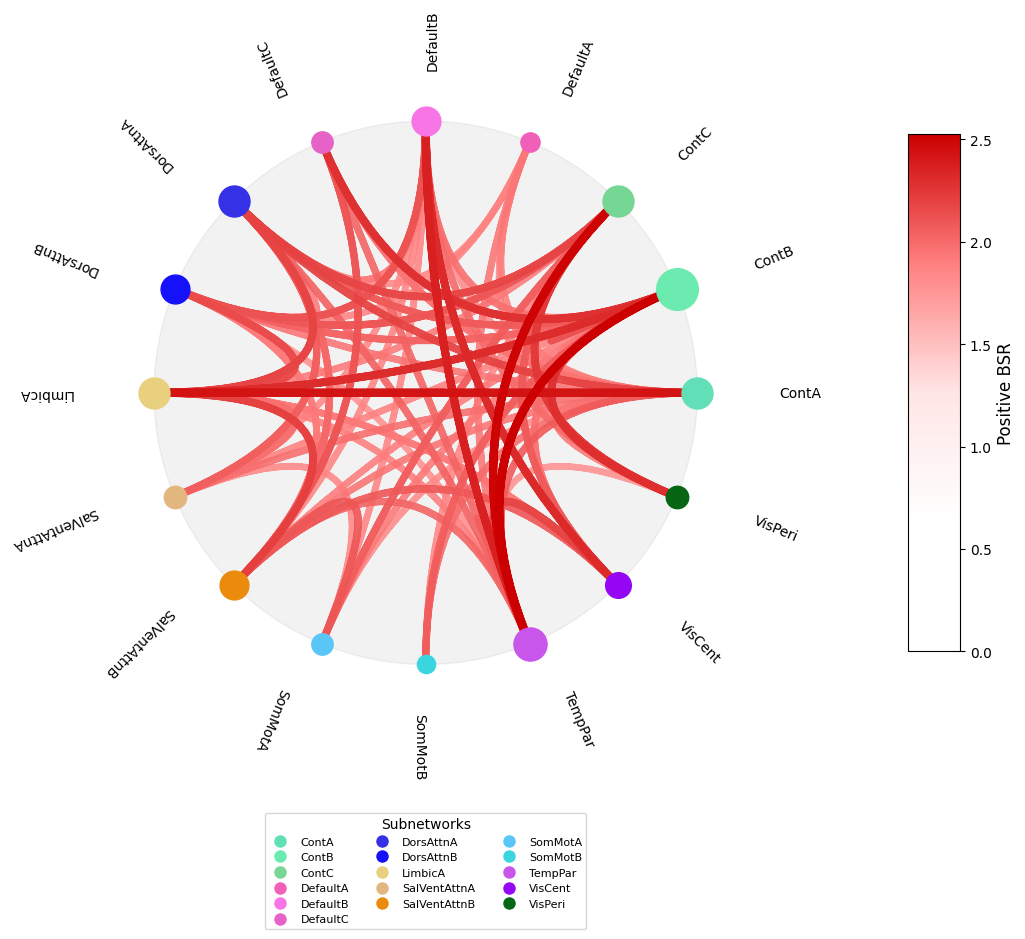

In [ ]:
plot_chord_diagram(BSR_LV1, mapping_dir, output_dir, positive=True, top_n=100, title="Top 100 Edges")


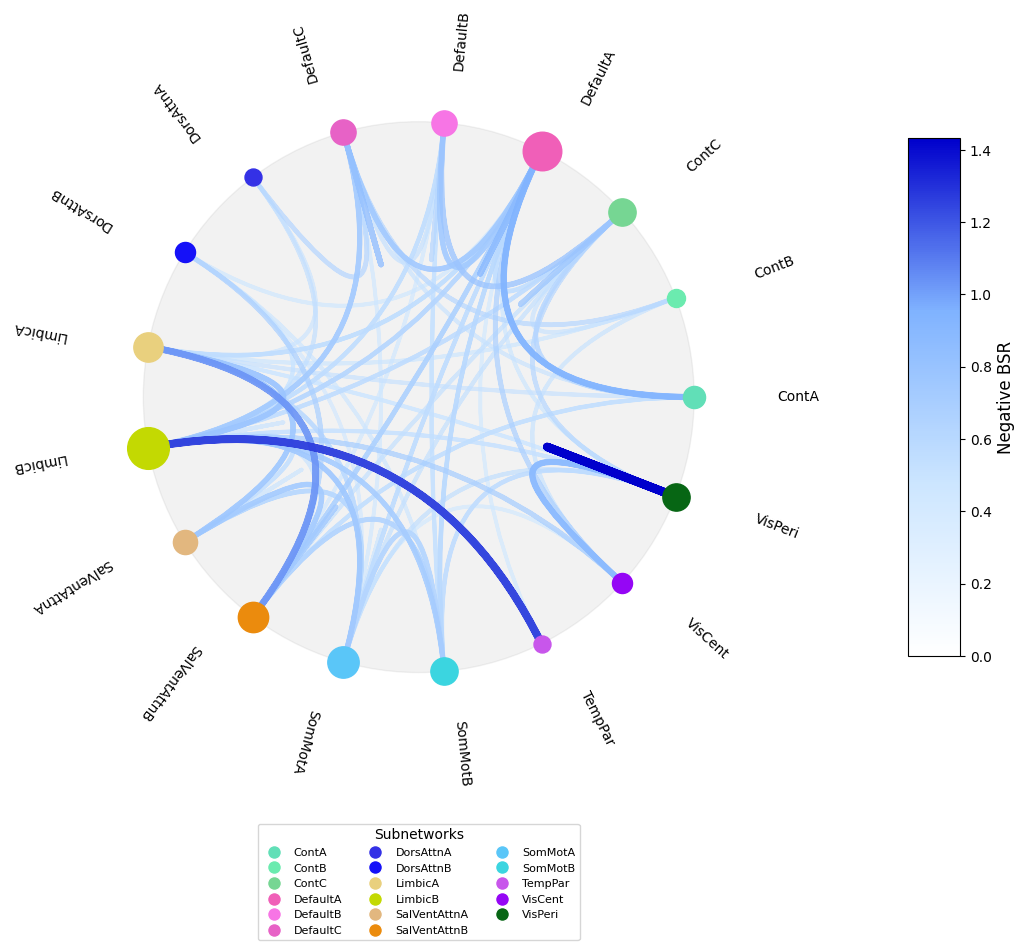

In [ ]:
plot_chord_diagram(BSR_LV1, mapping_dir, output_dir, positive=False, top_n=100, title="Top 100 Edges")
